In [1]:
import os, sys
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

In [2]:
# Set the current working directory
cwd = os.getcwd()

In [3]:
f_min = 1e-2
f_max = 1e10
f_steps = 20
output_file = 'freqP.dat'

In [4]:
# Read in tj data for all sims
N_t_bulk_values = ['0E20', '1E21', '3E21', '1E22']
sim_runs = []

for N_t_bulk in N_t_bulk_values:
    uuid = f'l2_N_t_bulk_{N_t_bulk}'
    
    # Read in tj.dat files
    tj_file_name = 'tj_' + uuid + '.dat'
    tj_data = pd.read_csv(tj_file_name, sep=r'\s+')

    # Save run data to a dictionary and store in sim_data
    run_data = {
        'N_t_bulk': N_t_bulk,
        'UUID': uuid,
        'tj_file': {
            'file_name': tj_file_name,
            'data': tj_data
        }
    }

    sim_runs.append(run_data)

In [5]:
# Calculate PL data for each run 
PL_layers = ['L2']

for run in sim_runs:
    PL_data = run['tj_file']['data'][f'Jdir{PL_layers[0]}']

    if len(PL_layers) > 1:
        for layer in PL_layers[1:]:
            PL_data += run['tj_file']['data'][f'Jdir{layer}']
    
    run['tj_file']['data']['PL'] = PL_data

In [6]:
# Generate the freqP files for each run
# for run in sim_runs:
#     uuid = run['UUID']
#     data = run['tj_file']['data']

#     output_file_base, output_file_ext = output_file.split('.')
#     freqP_file_name = output_file_base + '_' + uuid + '.' + output_file_ext

#     impls.get_IMPLS(data, f_min, f_max, f_steps, cwd, freqP_file_name)
    

In [7]:
# Read in the freqP data to the run dictionaries 
for run in sim_runs:
    uuid = run['UUID']

    # Read the files
    output_file_base, output_file_ext = output_file.split('.')
    freqP_file_name = output_file_base + '_' + uuid + '.' + output_file_ext
    freqP_data = pd.read_csv(freqP_file_name, sep=r'\s+')

    # Store freqP data in a dictionary 
    freqP_file_data = {
        'file_name': freqP_file_name,
        'data': freqP_data
    }

    # Save to the run dictionary 
    run['freqP_file'] = freqP_file_data


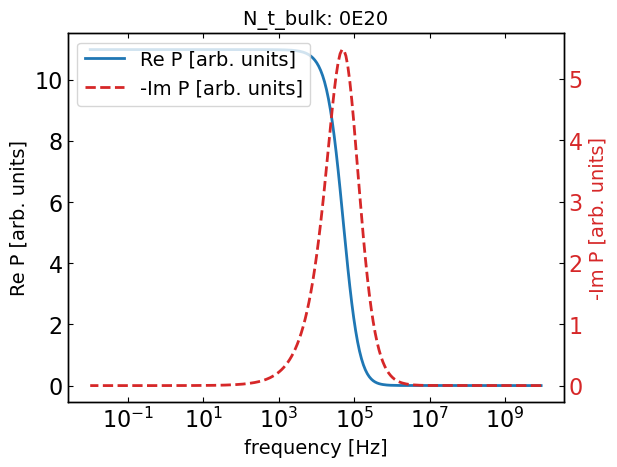

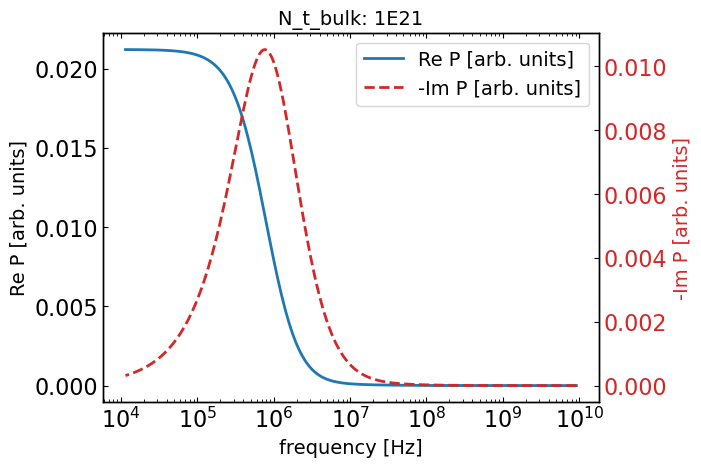

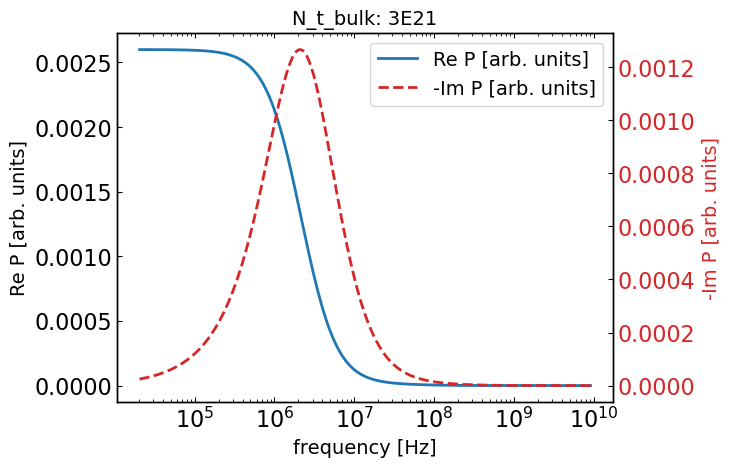

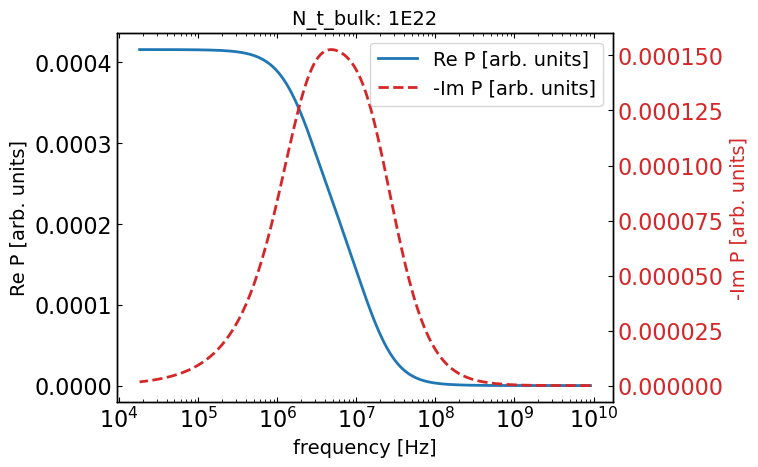

In [8]:
# Create a Bode Plot for each run
for run in sim_runs:
    impls.IMPLS_plot(cwd, run['freqP_file']['file_name'], xscale='log', yscale1='linear', yscale2='linear', title=f'N_t_bulk: {run['N_t_bulk']}')

In [9]:
# Find the characteristic RC frequency and lifetime for each
for run in sim_runs:
    freqP_file = run['freqP_file']
    max_ImP = freqP_file['data']['ImP'].abs().max()
    max_row = freqP_file['data'][freqP_file['data']['ImP'].abs() == max_ImP]
    max_freq = max_row['freq'].values[0]
    freqP_file['char_freq'] = max_freq
    freqP_file['char_lifetime'] = 1/(2*np.pi*max_freq)
    print(f"N_t_bulk: {run['N_t_bulk']}     char_lifetime: {run['freqP_file']['char_lifetime']:.3}")

N_t_bulk: 0E20     char_lifetime: 3.33e-06
N_t_bulk: 1E21     char_lifetime: 2.04e-07
N_t_bulk: 3E21     char_lifetime: 7.44e-08
N_t_bulk: 1E22     char_lifetime: 3.24e-08


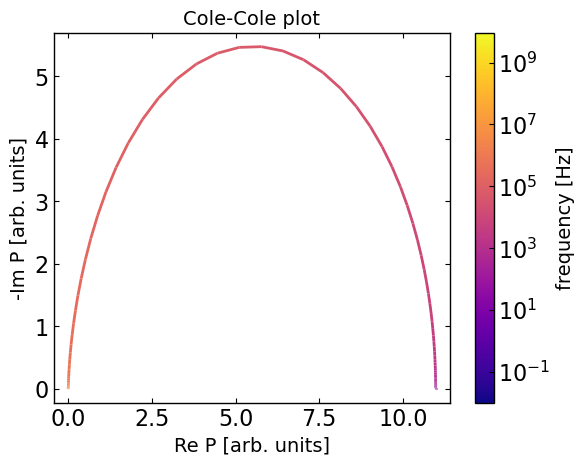

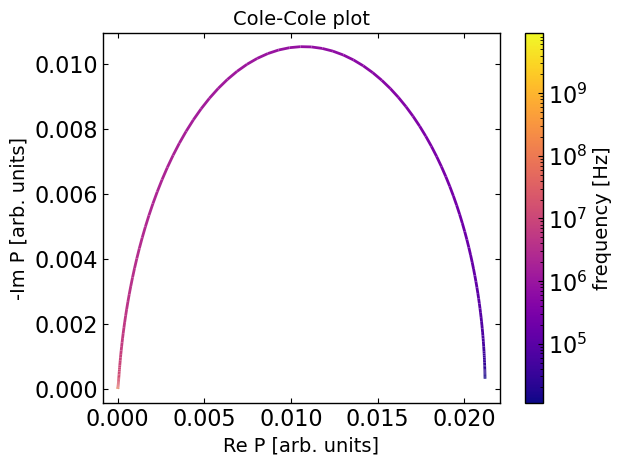

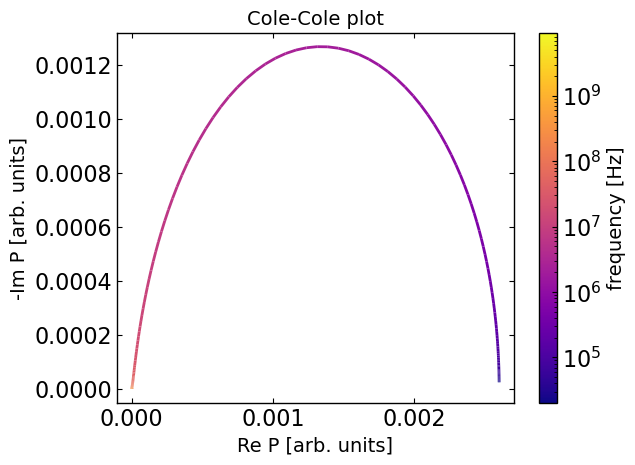

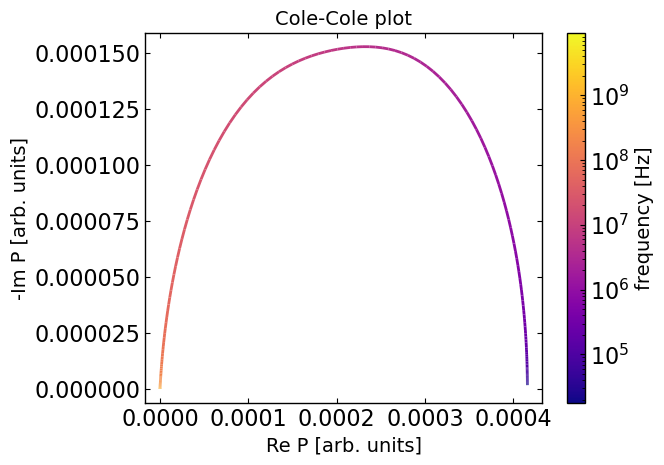

In [10]:
# Create a Nyquist Plot for each run
for run in sim_runs:
    impls.ColeCole_plot(cwd, run['freqP_file']['file_name'], plot=False)
    plt.show()

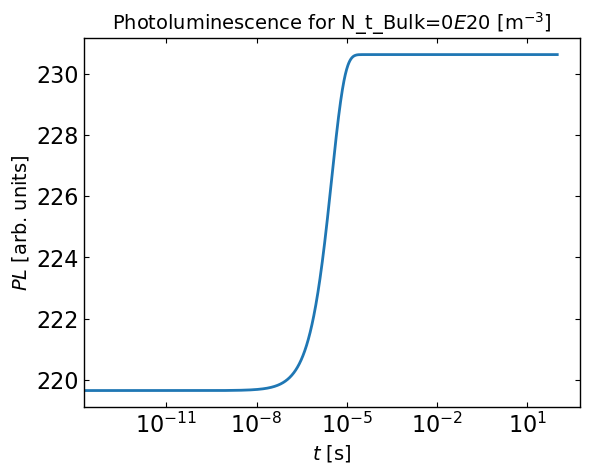

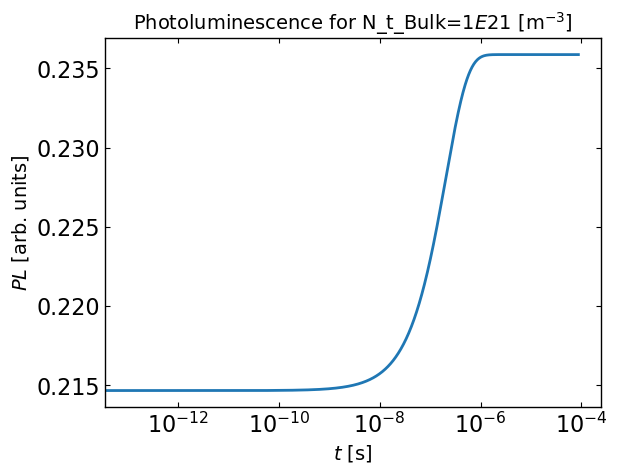

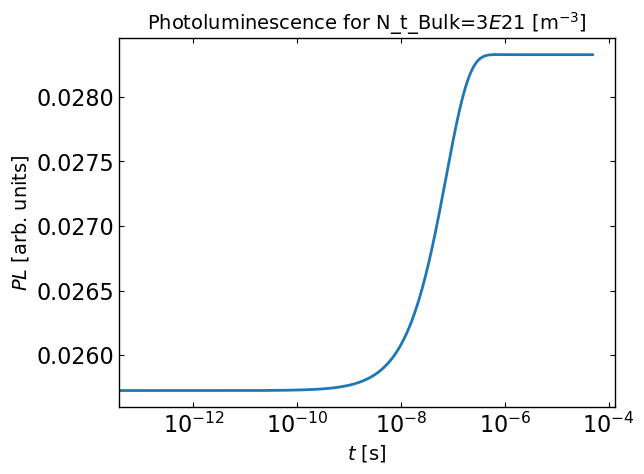

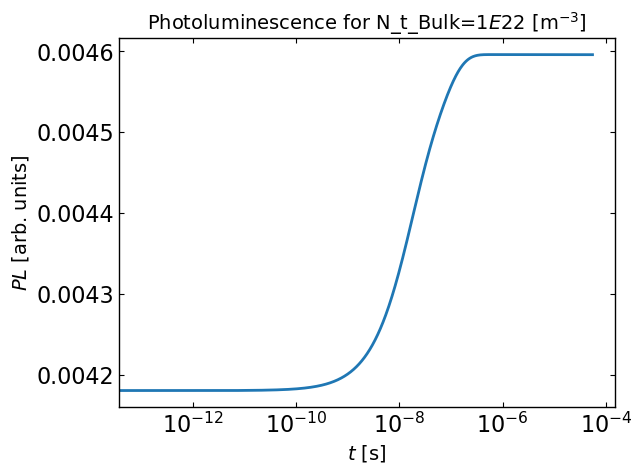

In [11]:
# For each of the runs, look at a plot in the time domain
for run in sim_runs:
    data = run['tj_file']['data']
    plt.plot(data['t'], data['PL'])
    plt.xscale('log')
    plt.xlabel('$t$ [$\\text{s}$]')
    plt.ylabel('$PL$ [arb. units]')
    plt.title(f"Photoluminescence for N_t_Bulk=${run['N_t_bulk']}$" + " [$\\text{m}^{-3}$]")
    plt.show()


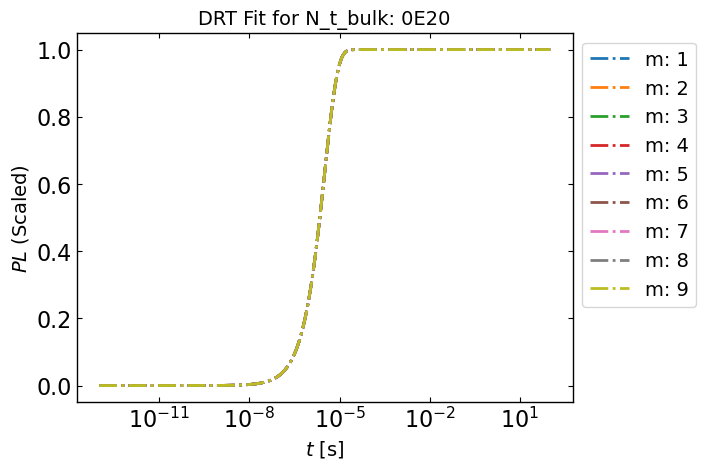

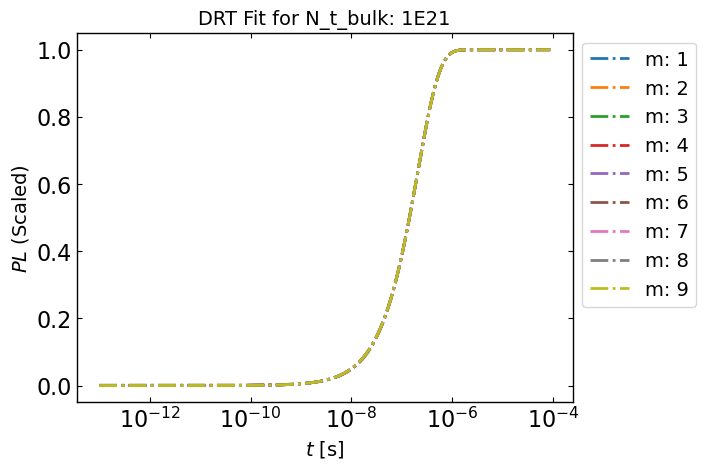

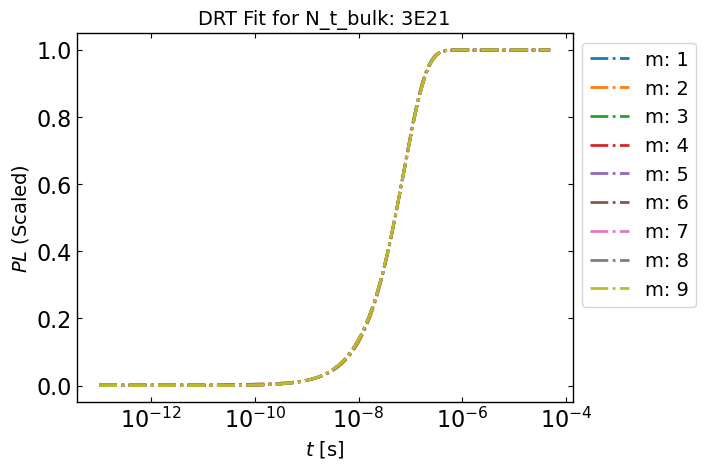

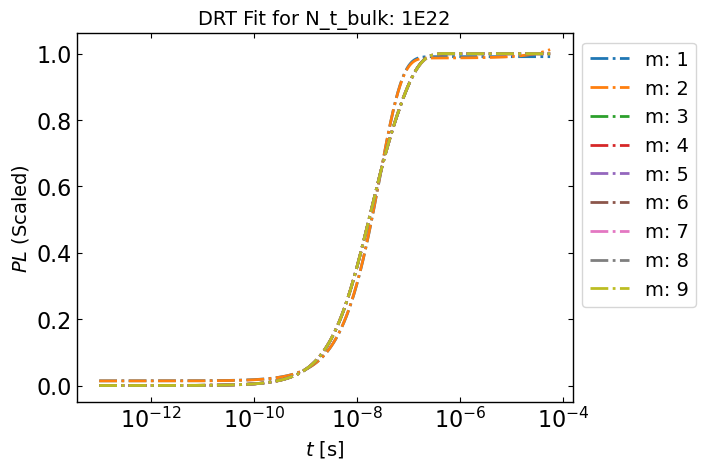

In [15]:
# Apply drt fitting for each run
for run in sim_runs:
    data = run['tj_file']['data']
    time = data['t'].values[1:]
    PL = data['PL'].values[1:]

    # Min-max scale the PL data 
    PL_scaled = (PL - PL.min())/(PL.max() - PL.min())

    polarity = 1 if time[-1] < time[0] else -1
    offset0 = PL_scaled.max() if polarity == 1 else PL_scaled.min()

    drt_fits = drt.multi_fit_DRT_curve(time, PL_scaled, range(1,10), U_scale_factor=-1, offset0=PL_scaled.max())

    for fit in drt_fits: 
            plt.plot(time, fit.DRT_curve, label=f"m: {fit.m}", linestyle="-.")
            plt.xscale('log')
            plt.xlabel('$t$ [$\\text{s}$]')
            plt.ylabel('$PL$ (Scaled)')
            plt.title(f"DRT Fit for N_t_bulk: {run['N_t_bulk']}")
            plt.legend(bbox_to_anchor=(1,1), loc='upper left')
    
#     plt.plot(time, PL_scaled, label='Sim')

    plt.show()
